# 06 - Baseline

**Regras duras:**
- O conjunto de TESTE nao e carregado neste notebook. Nenhuma linha de codigo o menciona.
  Toda avaliacao e na VALIDACAO.
- Nenhuma estatistica e calculada sobre validacao ou teste. O scaler e ajustado (fit)
  SOMENTE no treino e aplicado (transform) na validacao.
- Nenhum tratamento de desbalanceamento (sem class_weight, sem SMOTE). Os modelos
  produzem probabilidades; o threshold e escolhido depois, pelo lucro.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                              confusion_matrix, precision_score, recall_score, f1_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'
FAMILY_COLOR = {'M0b': '#888888', 'M1': '#0072B2', 'M2': '#009E73', 'M3': '#D55E00'}

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
validation = pd.read_parquet(PROCESSED_DIR / 'validation.parquet')
print('train:', train.shape)
print('validation:', validation.shape)


train: (172988, 89)
validation: (162570, 89)


### Recriando FEATURE_SET (79 colunas, definido em 05_feature_engineering.ipynb)

In [2]:
EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']
assert len(family_C_features) == 65

engineered_flags = ['era_pre_2012',
                     'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
                     'mths_since_recent_bc_dlq_missing', 'mths_since_recent_revol_delinq_missing',
                     'mths_since_last_major_derog_missing', 'emp_length_missing',
                     'mths_since_recent_inq_missing', 'num_tl_120dpd_2m_missing', 'sparse_bureau_missing']
assert len(engineered_flags) == 10

new_features = ['installment_to_income', 'loan_to_income', 'credit_history_months',
                 'revol_bal_to_income', 'open_acc_ratio']
assert len(new_features) == 5

redundant_cols = {'fico_range_high': 'redundancia (r=1.0 com fico_range_low)'}

FEATURE_SET = [c for c in family_C_features if c not in redundant_cols] + engineered_flags + new_features
assert len(FEATURE_SET) == 79, f'FEATURE_SET tem {len(FEATURE_SET)} colunas, esperado 79'
assert all(c in train.columns for c in FEATURE_SET)

CATEGORICAL_COLS = ['home_ownership', 'purpose', 'verification_status', 'initial_list_status', 'application_type']
REFERENCE_DATE = pd.Timestamp('2000-01-01')

print(f'FEATURE_SET recriado: {len(FEATURE_SET)} colunas.')


FEATURE_SET recriado: 79 colunas.


## Secao 1 - Calculo do resultado financeiro

Usando apenas colunas EVAL_ONLY: retorno se pago = (installment * term) - loan_amnt;
perda se calote = loan_amnt - total_rec_prncp.

In [3]:
def compute_financials(df):
    interest = (df['installment'] * df['term']) - df['loan_amnt']
    loss_raw = df['loan_amnt'] - df['total_rec_prncp']
    return interest, loss_raw

interest_train_raw, loss_train_raw = compute_financials(train)
interest_val_raw, loss_val_raw = compute_financials(validation)

fully_paid_train = train['target'] == 0
fully_paid_val = validation['target'] == 0
charged_off_train = train['target'] == 1
charged_off_val = validation['target'] == 1

print('1. Retorno (juros) entre Fully Paid:')
print(f'   treino     - mediana={interest_train_raw[fully_paid_train].median():,.2f} | media={interest_train_raw[fully_paid_train].mean():,.2f}')
print(f'   validacao  - mediana={interest_val_raw[fully_paid_val].median():,.2f} | media={interest_val_raw[fully_paid_val].mean():,.2f}')


1. Retorno (juros) entre Fully Paid:
   treino     - mediana=2,023.62 | media=2,427.36
   validacao  - mediana=1,981.68 | media=2,455.37


In [4]:
print('2. Perda (principal nao recuperado) entre Charged Off (valores brutos, antes de tratar negativos):')
print(f'   treino     - mediana={loss_train_raw[charged_off_train].median():,.2f} | media={loss_train_raw[charged_off_train].mean():,.2f}')
print(f'   validacao  - mediana={loss_val_raw[charged_off_val].median():,.2f} | media={loss_val_raw[charged_off_val].mean():,.2f}')


2. Perda (principal nao recuperado) entre Charged Off (valores brutos, antes de tratar negativos):
   treino     - mediana=5,398.84 | media=6,727.62
   validacao  - mediana=5,442.89 | media=6,929.42


In [5]:
ratio_train = loss_train_raw[charged_off_train].median() / interest_train_raw[fully_paid_train].median()
ratio_val = loss_val_raw[charged_off_val].median() / interest_val_raw[fully_paid_val].median()
print('3. Razao perda mediana / retorno mediano:')
print(f'   treino: {ratio_train:.4f}')
print(f'   validacao: {ratio_val:.4f}')


3. Razao perda mediana / retorno mediano:
   treino: 2.6679
   validacao: 2.7466


In [6]:
n_neg_train_all = int((loss_train_raw < 0).sum())
n_neg_train_co = int((loss_train_raw[charged_off_train] < 0).sum())
n_neg_val_all = int((loss_val_raw < 0).sum())
n_neg_val_co = int((loss_val_raw[charged_off_val] < 0).sum())

print('4. Casos de perda negativa (total_rec_prncp > loan_amnt):')
print(f'   treino    - todas as linhas: {n_neg_train_all:,} | so Charged Off: {n_neg_train_co:,}')
print(f'   validacao - todas as linhas: {n_neg_val_all:,} | so Charged Off: {n_neg_val_co:,}')
print()
print('   SINALIZADO: tratando perda negativa como perda zero (clip lower=0) a partir daqui.')

interest_train, loss_train = interest_train_raw, loss_train_raw.clip(lower=0)
interest_val, loss_val = interest_val_raw, loss_val_raw.clip(lower=0)


4. Casos de perda negativa (total_rec_prncp > loan_amnt):
   treino    - todas as linhas: 63 | so Charged Off: 0
   validacao - todas as linhas: 7 | so Charged Off: 0

   SINALIZADO: tratando perda negativa como perda zero (clip lower=0) a partir daqui.


In [7]:
profit_all_approved_train = interest_train[fully_paid_train].sum() - loss_train[charged_off_train].sum()
profit_all_approved_val = interest_val[fully_paid_val].sum() - loss_val[charged_off_val].sum()

print('5. Lucro total da carteira se todos os emprestimos forem aprovados (perda ja clipada em 0):')
print(f'   treino:    $ {profit_all_approved_train:,.2f}')
print(f'   validacao: $ {profit_all_approved_val:,.2f}')


5. Lucro total da carteira se todos os emprestimos forem aprovados (perda ja clipada em 0):
   treino:    $ 222,998,642.91
   validacao: $ 189,747,912.27


In [8]:
def profit_at_threshold(y_true, y_prob, threshold, interest, loss):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    interest = np.asarray(interest)
    loss = np.asarray(loss)
    aprovados = y_prob < threshold
    lucro = interest[aprovados & (y_true == 0)].sum() - loss[aprovados & (y_true == 1)].sum()
    return lucro

print('profit_at_threshold definida.')


profit_at_threshold definida.


## Secao 2 - Referencias sem aprendizado

In [9]:
dummy_model = DummyClassifier(strategy='prior', random_state=42)
dummy_model.fit(np.zeros((len(train), 1)), train['target'].values)

y_prob_val_m0a = dummy_model.predict_proba(np.zeros((len(validation), 1)))[:, 1]
constant_prob = dummy_model.predict_proba(np.zeros((1, 1)))[0, 1]

auc_roc_m0a = roc_auc_score(validation['target'].values, y_prob_val_m0a)
auc_pr_m0a = average_precision_score(validation['target'].values, y_prob_val_m0a)

print('M0a - DummyClassifier(strategy=prior)')
print(f'  Probabilidade constante emitida: {constant_prob:.6f}')
print(f'  (taxa de default do treino, para comparacao: {train["target"].mean():.6f})')
print(f'  AUC-ROC: {auc_roc_m0a:.4f} (esperado: 0.5)')
print(f'  AUC-PR: {auc_pr_m0a:.4f}')


M0a - DummyClassifier(strategy=prior)
  Probabilidade constante emitida: 0.124332
  (taxa de default do treino, para comparacao: 0.124332)
  AUC-ROC: 0.5000 (esperado: 0.5)
  AUC-PR: 0.1373


In [10]:
profit_m0b = profit_at_threshold(validation['target'].values, np.zeros(len(validation)), 1.01,
                                  interest_val.values, loss_val.values)
print('M0b - politica "aprova todos"')
print(f'  Lucro da carteira inteira na validacao: $ {profit_m0b:,.2f}')
print(f'  (deve bater com o item 5 da Secao 1: $ {profit_all_approved_val:,.2f})')
print()
print('Esta e a linha que o projeto precisa superar (criterio de sucesso 1 do scope.md).')


M0b - politica "aprova todos"
  Lucro da carteira inteira na validacao: $ 189,747,912.27
  (deve bater com o item 5 da Secao 1: $ 189,747,912.27)

Esta e a linha que o projeto precisa superar (criterio de sucesso 1 do scope.md).


## Secao 3 - Regressao Logistica: tres variantes

StandardScaler ajustado so no treino de cada variante. Colunas categoricas via one-hot
(drop_first). issue_d e earliest_cr_line (datetime, presentes no FEATURE_SET) sao
convertidas para numerico (dias desde uma data de referencia fixa) so para viabilizar o
ajuste do modelo - nao e uma feature nova, e uma codificacao da feature ja selecionada.

In [11]:
def prepare_X(df, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for c in ['issue_d', 'earliest_cr_line']:
        if c in X.columns:
            X[c] = (X[c] - REFERENCE_DATE).dt.days
    cat_present = [c for c in categorical_cols if c in X.columns]
    X = pd.get_dummies(X, columns=cat_present, drop_first=True)
    return X


def fit_logistic_pipeline(train_df, val_df, feature_cols, categorical_cols, model_name, max_iter=2000):
    X_train_raw = prepare_X(train_df, feature_cols, categorical_cols)
    X_val_raw = prepare_X(val_df, feature_cols, categorical_cols)
    X_val_raw = X_val_raw.reindex(columns=X_train_raw.columns, fill_value=0)

    y_train = train_df['target'].values
    y_val = val_df['target'].values

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=max_iter, random_state=42)
        model.fit(X_train_scaled, y_train)
        conv_warn = any(issubclass(warning.category, ConvergenceWarning) for warning in w)

    n_iter = int(np.ravel(model.n_iter_)[0])
    print(f'{model_name}: n_features={X_train_scaled.shape[1]} | n_iter_={n_iter} (max_iter={max_iter}) | ConvergenceWarning={conv_warn}')
    if conv_warn or n_iter >= max_iter:
        raise RuntimeError(f'PARANDO: {model_name} nao convergiu (n_iter_={n_iter} >= max_iter={max_iter} ou ConvergenceWarning emitido).')
    print(f'{model_name}: convergiu.')

    return {'model': model, 'scaler': scaler, 'X_train': X_train_scaled, 'X_val': X_val_scaled,
            'y_train': y_train, 'y_val': y_val, 'feature_names': list(X_train_scaled.columns)}


### M1 - baseline completo

In [12]:
m1 = fit_logistic_pipeline(train, validation, FEATURE_SET, CATEGORICAL_COLS, 'M1')


M1: n_features=90 | n_iter_=84 (max_iter=2000) | ConvergenceWarning=False
M1: convergiu.


### M2 - sem safras pre-2012

Identifica programaticamente as colunas cujo valor -1 aparece EXCLUSIVAMENTE em linhas
com era_pre_2012==1 no treino completo (nao uma lista fixa).

In [13]:
sentinel_neg1_cols = []
for c in FEATURE_SET:
    if c == 'era_pre_2012':
        continue
    if not pd.api.types.is_numeric_dtype(train[c]):
        continue
    neg1_mask = train[c] == -1
    n_neg1 = int(neg1_mask.sum())
    if n_neg1 == 0:
        continue
    exclusively_pre2012 = bool((train.loc[neg1_mask, 'era_pre_2012'] == 1).all())
    if exclusively_pre2012:
        sentinel_neg1_cols.append(c)

print(f'Colunas com -1 exclusivamente em era_pre_2012==1 no treino completo: {len(sentinel_neg1_cols)}')
print(sentinel_neg1_cols)
print()
print('Nota: o enunciado estimava "~24" colunas; a contagem exata medida pelo criterio programatico')
print('prevalece (a regra pedida - "identifique-as programaticamente" - e a fonte da verdade, nao a estimativa).')


Colunas com -1 exclusivamente em era_pre_2012==1 no treino completo: 23
['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'mo_sin_rcnt_tl', 'mort_acc', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']

Nota: o enunciado estimava "~24" colunas; a contagem exata medida pelo criterio programatico
prevalece (a regra pedida - "identifique-as programaticamente" - e a fonte da verdade, nao a estimativa).


In [14]:
m2_removed_cols = ['era_pre_2012'] + sentinel_neg1_cols
m2_feature_set = [c for c in FEATURE_SET if c not in m2_removed_cols]

train_m2 = train.loc[train['era_pre_2012'] == 0].copy()

print(f'Colunas removidas do feature set do M2: {len(m2_removed_cols)} -> {m2_removed_cols}')
print(f'Feature set do M2: {len(m2_feature_set)} colunas')
print(f'N do treino M2 (era_pre_2012 == 0): {len(train_m2):,} (treino completo tem {len(train):,})')


Colunas removidas do feature set do M2: 24 -> ['era_pre_2012', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'mo_sin_rcnt_tl', 'mort_acc', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']
Feature set do M2: 55 colunas
N do treino M2 (era_pre_2012 == 0): 121,342 (treino completo tem 172,988)


In [15]:
m2 = fit_logistic_pipeline(train_m2, validation, m2_feature_set, CATEGORICAL_COLS, 'M2')


M2: n_features=66 | n_iter_=50 (max_iter=2000) | ConvergenceWarning=False
M2: convergiu.


### M3 - com o julgamento da plataforma

79 features + int_rate, grade, sub_grade. grade e sub_grade via one-hot (nao ordinal).

In [16]:
m3_feature_set = FEATURE_SET + ['int_rate', 'grade', 'sub_grade']
m3_categorical_cols = CATEGORICAL_COLS + ['grade', 'sub_grade']

m3 = fit_logistic_pipeline(train, validation, m3_feature_set, m3_categorical_cols, 'M3')


M3: n_features=131 | n_iter_=99 (max_iter=2000) | ConvergenceWarning=False
M3: convergiu.


## Secao 4 - Avaliacao na validacao

In [17]:
def evaluate_model(y_true, y_prob, name):
    auc_roc = roc_auc_score(y_true, y_prob)
    auc_pr = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {'modelo': name, 'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
            'brier': round(brier, 4), 'tn': cm[0, 0], 'fp': cm[0, 1], 'fn': cm[1, 0], 'tp': cm[1, 1],
            'precision_0.5': round(precision, 4), 'recall_0.5': round(recall, 4), 'f1_0.5': round(f1, 4)}


y_prob_val_m1 = m1['model'].predict_proba(m1['X_val'])[:, 1]
y_prob_val_m2 = m2['model'].predict_proba(m2['X_val'])[:, 1]
y_prob_val_m3 = m3['model'].predict_proba(m3['X_val'])[:, 1]

y_val = validation['target'].values

eval_rows = [
    evaluate_model(y_val, y_prob_val_m0a, 'M0a'),
    evaluate_model(y_val, y_prob_val_m1, 'M1'),
    evaluate_model(y_val, y_prob_val_m2, 'M2'),
    evaluate_model(y_val, y_prob_val_m3, 'M3'),
]

pd.DataFrame(eval_rows).set_index('modelo')


,auc_roc,auc_pr,brier,tn,fp,fn,tp,precision_0.5,recall_0.5,f1_0.5
modelo,,,,,,,,,,
M0a,0.5000,0.1373,0.1186,140255,0,22315,0,0.0000,0.0000,0.0000
M1,0.6765,0.2389,0.1132,140071,184,22211,104,0.3611,0.0047,0.0092
M2,0.6723,0.2335,0.1137,140053,202,22205,110,0.3526,0.0049,0.0097
M3,0.6804,0.2394,0.1130,140052,203,22202,113,0.3576,0.0051,0.0100


## Secao 5 - Curva de lucro por threshold

In [18]:
thresholds = np.round(np.arange(0.01, 1.0, 0.01), 2)

y_prob_by_model = {'M1': y_prob_val_m1, 'M2': y_prob_val_m2, 'M3': y_prob_val_m3}
profit_curves = {}

for name, y_prob in y_prob_by_model.items():
    profits = [profit_at_threshold(y_val, y_prob, t, interest_val.values, loss_val.values) for t in thresholds]
    profit_curves[name] = np.array(profits)

summary_rows = []
for name, profits in profit_curves.items():
    best_idx = int(np.argmax(profits))
    best_threshold = thresholds[best_idx]
    best_profit = profits[best_idx]
    aprovados = y_prob_by_model[name] < best_threshold
    pct_aprovados = aprovados.mean() * 100
    default_rate_aprovados = y_val[aprovados].mean() * 100 if aprovados.sum() > 0 else np.nan
    summary_rows.append({'modelo': name, 'threshold_otimo': best_threshold, 'lucro_otimo': round(best_profit, 2),
                          '%_aprovados': round(pct_aprovados, 2), 'default_%_entre_aprovados': round(default_rate_aprovados, 4),
                          'lucro_vs_M0b': round(best_profit - profit_m0b, 2)})

profit_summary = pd.DataFrame(summary_rows).set_index('modelo')
print(f'Referencia M0b (aprova todos): $ {profit_m0b:,.2f}')
profit_summary


Referencia M0b (aprova todos): $ 189,747,912.27


,threshold_otimo,lucro_otimo,%_aprovados,default_%_entre_aprovados,lucro_vs_M0b
modelo,,,,,
M1,0.38,1.906221e+08,98.92,13.4729,874222.01
M2,0.37,1.901494e+08,98.95,13.4860,401468.52
M3,0.34,1.906727e+08,98.17,13.3332,924768.38


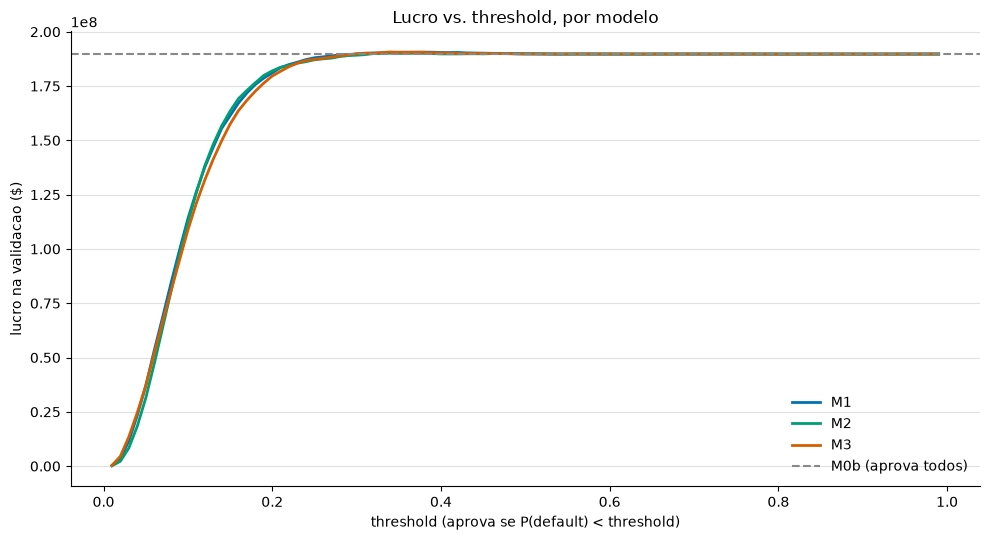

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, profits in profit_curves.items():
    ax.plot(thresholds, profits, linewidth=2, color=FAMILY_COLOR[name], label=name)
ax.axhline(profit_m0b, color=FAMILY_COLOR['M0b'], linestyle='--', linewidth=1.5, label='M0b (aprova todos)')
ax.set_xlabel('threshold (aprova se P(default) < threshold)')
ax.set_ylabel('lucro na validacao ($)')
ax.set_title('Lucro vs. threshold, por modelo')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## Secao 6 - Diagnostico de colinearidade e coeficientes (M1 apenas)

In [20]:
coef_df = pd.DataFrame({'feature': m1['feature_names'], 'coef': m1['model'].coef_[0]})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_sorted = coef_df.sort_values('coef', ascending=False).reset_index(drop=True)

print('15 maiores coeficientes:')
display(coef_sorted.head(15)[['feature', 'coef']])
print()
print('15 menores coeficientes:')
display(coef_sorted.tail(15)[['feature', 'coef']].sort_values('coef'))


15 maiores coeficientes:


,feature,coef
0,installment_to_income,1.283392
1,percent_bc_gt_75,0.657203
2,mths_since_last_record,0.257128
3,acc_open_past_24mths,0.188776
4,pct_tl_nvr_dlq,0.178626
5,num_rev_tl_bal_gt_0,0.149881
6,inq_last_6mths,0.123741
7,era_pre_2012,0.119233
8,purpose_small_business,0.118497
9,num_bc_tl,0.108885



15 menores coeficientes:


,feature,coef
89,loan_to_income,-1.033658
88,bc_util,-0.345388
87,mths_since_last_record_missing,-0.245403
86,fico_range_low,-0.239745
85,mths_since_recent_bc,-0.220096
84,total_bc_limit,-0.152998
83,avg_cur_bal,-0.112565
82,mo_sin_old_rev_tl_op,-0.099829
81,funded_amnt,-0.093715
80,total_acc,-0.092812


In [21]:
top20_features = coef_df.sort_values('abs_coef', ascending=False).head(20)['feature'].tolist()

X_vif = m1['X_train'][top20_features]
X_vif_const = add_constant(X_vif)

vif_rows = []
for i, col in enumerate(X_vif.columns):
    vif = variance_inflation_factor(X_vif_const.values, i + 1)
    vif_rows.append({'feature': col, 'vif': round(vif, 2), 'sinalizacao': 'VIF > 10' if vif > 10 else ''})

vif_df = pd.DataFrame(vif_rows).sort_values('vif', ascending=False).reset_index(drop=True)
vif_df


,feature,vif,sinalizacao
0,mths_since_last_record,815.41,VIF > 10
1,mths_since_last_record_missing,815.03,VIF > 10
2,percent_bc_gt_75,267.31,VIF > 10
3,bc_util,265.64,VIF > 10
4,mths_since_recent_bc,92.80,VIF > 10
5,installment_to_income,91.58,VIF > 10
6,loan_to_income,89.57,VIF > 10
7,era_pre_2012,55.33,VIF > 10
8,pct_tl_nvr_dlq,48.68,VIF > 10
9,num_rev_tl_bal_gt_0,3.68,


In [22]:
specific_cols = ['era_pre_2012', 'initial_list_status', 'verification_status',
                  'installment_to_income', 'fico_range_low']

print('Coeficientes especificos (colunas categoricas mostram todas as dummies geradas):')
for base_col in specific_cols:
    matches = coef_df[coef_df['feature'] == base_col]
    if len(matches) == 0:
        matches = coef_df[coef_df['feature'].str.startswith(base_col + '_')]
    if len(matches) == 0:
        print(f'  {base_col}: NENHUM coeficiente encontrado (categoria de referencia do one-hot, ou ausente).')
        continue
    for _, row in matches.iterrows():
        print(f"  {row['feature']}: {row['coef']:.4f}")


Coeficientes especificos (colunas categoricas mostram todas as dummies geradas):
  era_pre_2012: 0.1192
  initial_list_status_w: -0.0025
  verification_status_source verified: 0.0166
  verification_status_verified: -0.0093
  installment_to_income: 1.2834
  fico_range_low: -0.2397


## Secao 7 - Nota de leitura

Se a diferenca de lucro entre M1, M2 e M3 (Secao 5) for pequena em relacao a propria
variacao da curva de lucro ao longo dos thresholds - isto e, se mover o threshold em
poucos pontos percentuais muda o lucro de um modelo mais do que a diferenca entre os
modelos no ponto otimo - a escolha entre eles **nao esta estabelecida por esta evidencia**.
Um ranking de lucro pontual, sem intervalo de incerteza, pode inverter com uma amostra
diferente ou um threshold vizinho.

O proximo passo necessario, antes de declarar um modelo vencedor, e:
1. Intervalo de confianca por bootstrap sobre o lucro no threshold otimo de cada modelo
   (reamostrar a validacao com reposicao, recalcular o lucro, repetir centenas de vezes).
2. Estabilidade do threshold otimo sob essas reamostragens (o otimo muda muito de uma
   reamostra para outra? Se sim, o "threshold otimo" reportado aqui e ruidoso, nao um
   parametro confiavel).

Nenhuma conclusao de superioridade entre M1, M2 e M3 e feita nesta fase. Os numeros acima
sao evidencia inicial, nao veredito.